# NB03 — Modellazione e validazione (GLM)

**Obiettivo.** Stimare il burning cost individuale con modelli interpretabili su uno split temporale
onesto (train uy 1-2 / test uy 3) e validarli nell'ottica del **monitoraggio di portafoglio**.

**Parte A — Modellazione**: GLM di frequenza (Poisson, offset = esposizione), GLM di
severity (Gamma, pesi = n. sinistri), Tweedie come alternativa a modello unico, fattori tariffari.

**Parte B — Valutazione e validazione**: confronto tra i modelli (Gini, MAE),
A/E complessivo e per segmento, lift table, Gini con intervallo di confidenza bootstrap,
sovra-dispersione.

## 0. Setup e caricamento

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.simplefilter('ignore')
sns.set_theme(style='whitegrid', palette='deep')
Log = sm.families.links.Log

REP_DIR = '../reports'
os.makedirs(REP_DIR, exist_ok=True)

df = pd.read_csv('../data/processed/base_modellabile.csv.gz')
print('Base modellabile:', df.shape)
print(df['split'].value_counts().to_string())

Base modellabile: (78964, 36)
split
train    54456
test     24508


## 1. Selezione delle feature

**RHS** = predittori del modello: anagrafiche e di polizza
(fascia di eta, sesso, categoria, legame familiare, settore, macroarea) piu' struttura del nucleo
(composizione), dimensione dell'azienda (in scala log) e interazione eta x sesso.

In [2]:
CAT = ['fascia_eta', 'sesso', 'categoria', 'legame_familiare', 'settore', 'macroarea']
NUM = ['composizione_num', 'log_dim_azienda']
INT = ['C(fascia_eta):C(sesso)']   # interazione eta x sesso 

REF={'categoria':'DIP_BASE'}
CAT_TERMS=[f"C({c}, Treatment(reference='{REF[c]}'))" if c in REF else f"C({c})" for c in CAT]
RHS='+'.join(CAT_TERMS+NUM+INT)


train = df[df['split'] == 'train'].copy()
test  = df[df['split'] == 'test'].copy()

# Guardia: i livelli categorici del test devono esistere nel train
for c in CAT:
    extra = set(test[c].unique()) - set(train[c].unique())
    if extra: print(f'ATTENZIONE: livelli solo nel test in {c}: {extra}')
print('Train:', train.shape, '| Test:', test.shape)
print('Burning cost medio (pesato) train: '
      f"{(train.costo_totale.sum()/train.esposizione.sum()):.2f} | "
      f"test: {(test.costo_totale.sum()/test.esposizione.sum()):.2f}")

Train: (54456, 36) | Test: (24508, 36)
Burning cost medio (pesato) train: 49.02 | test: 49.17


## 2. Modello di frequenza — GLM Poisson con offset

Modella il numero di sinistri con offset = log(esposizione) -> stima un tasso per anno-uomo.
Il link logaritmico rende i coefficienti moltiplicatori (fattori tariffari di frequenza).

In [3]:
freq_mod = smf.glm(f'n_sinistri ~ {RHS}', data=train, family=sm.families.Poisson(),
                   offset=np.log(train.esposizione)).fit()
print(f'Freq Poisson - deviance: {freq_mod.deviance:,.0f}')
mu_tr = freq_mod.predict(train, offset=np.log(train.esposizione))
print(f'Sanity offset: sinistri previsti {mu_tr.sum():,.0f} = osservati {train.n_sinistri.sum():,.0f}')

Freq Poisson - deviance: 77,447
Sanity offset: sinistri previsti 27,588 = osservati 27,588


## 3. Modello di severity — GLM Gamma (log link)

Stima il costo medio per sinistro, condizionato all'avvenuto sinistro (solo sinistrati). Distribuzione
Gamma (positiva, asimmetrica), link log, peso = numero di sinistri (un assicurato con piu' sinistri
pesa di piu' nella stima del costo medio).

In [4]:
clm = train[train.n_sinistri > 0].copy()
sev_mod = smf.glm(f'severity ~ {RHS}', data=clm,
                  family=sm.families.Gamma(link=Log()),
                  var_weights=clm.n_sinistri).fit()
print(f'Severity Gamma - n. sinistrati train: {len(clm):,} | deviance: {sev_mod.deviance:,.1f}')

Severity Gamma - n. sinistrati train: 13,255 | deviance: 15,015.8


## 4. Modello alternativo — Tweedie

Un unico GLM sul burning cost: la Tweedie con 1 < p < 2 gestisce nativamente la massa di zeri
(componente Poisson) e la coda positiva (componente Gamma). Pesato per esposizione. var_power = 1.5.

In [5]:
tw_mod = smf.glm(f'burning_cost ~ {RHS}', data=train,
                 family=sm.families.Tweedie(link=Log(), var_power=1.5),
                 var_weights=train.esposizione).fit()
print(f'Tweedie - deviance: {tw_mod.deviance:,.0f}')

Tweedie - deviance: 1,362,363


## 5. Fattori tariffari

Il vantaggio del modello spezzato: fattori separati per frequenza e severity. Si leggono come
moltiplicatori rispetto alla categoria di riferimento (es. 1,35 = +35% di rischio atteso).

## 6. Funzioni di valutazione

- **Gini normalizzato** (pesato per esposizione): capacita' di *ordinare* il rischio (1 = perfetto, 0 = casuale).
- **MAE pesato**: errore medio assoluto sul burning cost (metrica secondaria, dominata dagli zeri).
- **Lift table**: per decile di rischio previsto, confronta burning cost previsto vs osservato.

In [6]:
def norm_gini(actual, pred, weight):
    def area(a, p, w):
        d = pd.DataFrame({'a': a, 'p': p, 'w': w}).sort_values('p', ascending=False)
        cw = np.concatenate([[0], (d.w.cumsum() / d.w.sum()).values])
        cl = np.concatenate([[0], ((d.a * d.w).cumsum() / (d.a * d.w).sum()).values])
        return np.trapz(cl, cw) - 0.5
    g = area(actual, actual, weight)
    return area(actual, pred, weight) / g if g else 0.0

def lift_table(actual, pred, weight, q=10):
    d = pd.DataFrame({'a': actual, 'p': pred, 'w': weight})
    d['grp'] = pd.qcut(d['p'].rank(method='first'), q, labels=range(1, q + 1))
    d['aw'], d['pw'] = d.a * d.w, d.p * d.w
    g = d.groupby('grp', observed=True).agg(esposizione=('w', 'sum'), aw=('aw', 'sum'), pw=('pw', 'sum'))
    g['bc_previsto']  = g.pw / g.esposizione
    g['bc_osservato'] = g.aw / g.esposizione
    g['A_su_E']       = g.bc_osservato / g.bc_previsto
    return g[['esposizione', 'bc_previsto', 'bc_osservato', 'A_su_E']]

def mae_w(actual, pred, weight):
    return np.average(np.abs(actual - pred), weights=weight)

risultati = {}
def valuta(nome, pred_train, pred_test):
    r = {'gini_train': norm_gini(train.burning_cost.values, pred_train, train.esposizione.values),
         'gini_test' : norm_gini(test.burning_cost.values,  pred_test,  test.esposizione.values),
         'mae_test'  : mae_w(test.burning_cost.values, pred_test, test.esposizione.values)}
    risultati[nome] = r
    print(f"{nome} | Gini train {r['gini_train']:.3f} | Gini test {r['gini_test']:.3f} | MAE test {r['mae_test']:.2f}")
    return r
print('ok')

ok


## 7. Confronto dei modelli

- **Baseline (media di portafoglio)**: assegna a tutti lo stesso burning cost. Non ordina il rischio: e' il pavimento che ogni modello sensato deve battere.
- **Freq x Severity**: il modello scelto.
- **Tweedie**: l'alternativa a modello unico.

In [7]:
# Previsioni del modello scelto, calcolate una volta per tutta la validazione
def pred_bc(d):
    mu = freq_mod.predict(d, offset=np.log(d.esposizione))   # n. sinistri attesi
    return (mu / d.esposizione * sev_mod.predict(d)).values  # frequenza x severity

test = test.assign(pred_bc=pred_bc(test))
test['pred_cost'] = test.pred_bc * test.esposizione
print('Previsioni del modello scelto calcolate sul test.')

Previsioni del modello scelto calcolate sul test.


In [8]:
bc_medio = train.costo_totale.sum() / train.esposizione.sum()
valuta('0. Baseline (media)', np.full(len(train), bc_medio), np.full(len(test), bc_medio));
valuta('1. Freq x Severity', pred_bc(train), test.pred_bc.values);
valuta('2. Tweedie', tw_mod.predict(train).values, tw_mod.predict(test).values);

0. Baseline (media) | Gini train -0.008 | Gini test 0.004 | MAE test 74.43
1. Freq x Severity | Gini train 0.466 | Gini test 0.455 | MAE test 67.01
2. Tweedie | Gini train 0.453 | Gini test 0.450 | MAE test 67.10


## 8. Calibrazione complessiva (Actual vs Expected totale)

Il premio totale deve coprire i sinistri attesi. Confronto costo totale osservato vs previsto sul test.
> Nota: il modello freq x severity (a differenza della sola Poisson con offset) **non bilancia
> automaticamente** il totale: un eventuale scostamento e' una calibrazione da correggere (rescale del livello).

In [9]:
costo_oss  = test.costo_totale.sum()
costo_prev = test.pred_cost.sum()
print(f'Costo totale OSSERVATO (test): {costo_oss:,.0f}')
print(f'Costo totale PREVISTO  (test): {costo_prev:,.0f}')
print(f'A/E complessivo: {costo_oss / costo_prev:.3f}   (1.00 = perfettamente bilanciato)')
print(f'Burning cost medio:  osservato {costo_oss/test.esposizione.sum():.2f} | '
      f'previsto {costo_prev/test.esposizione.sum():.2f}')

Costo totale OSSERVATO (test): 1,154,809
Costo totale PREVISTO  (test): 1,106,297
A/E complessivo: 1.044   (1.00 = perfettamente bilanciato)
Burning cost medio:  osservato 49.17 | previsto 47.11


## 9. Calibrazione per decile di rischio (lift table)

Ordino il test per rischio previsto, divido in 10 decili di pari esposizione, confronto previsto vs osservato.
Buon segno: osservato **crescente** dal decile 1 al 10 e **A/E ~ 1** in ogni decile.

     esposizione  bc_previsto  bc_osservato  A_su_E
grp                                                
1        2316.15        5.569         1.767   0.317
2        2319.95       10.607         5.101   0.481
3        2355.24       20.363        23.437   1.151
4        2364.21       28.278        34.349   1.215
5        2356.17       36.204        47.998   1.326
6        2348.01       43.015        47.504   1.104
7        2349.14       51.328        58.613   1.142
8        2348.25       63.904        63.371   0.992
9        2371.20       80.177        79.345   0.990
10       2357.08      130.211       128.634   0.988


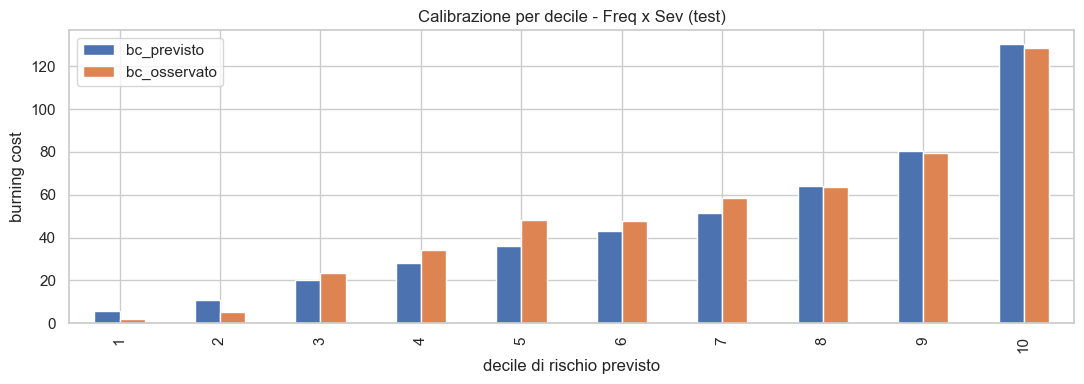

In [10]:
lt = lift_table(test.burning_cost.values, test.pred_bc.values, test.esposizione.values, q=10)
print(lt.round(3).to_string())

ax = lt[['bc_previsto', 'bc_osservato']].plot.bar(figsize=(11, 4))
ax.set_title('Calibrazione per decile - Freq x Sev (test)')
ax.set_xlabel('decile di rischio previsto'); ax.set_ylabel('burning cost')
plt.tight_layout(); plt.show()

## 10. Actual vs Expected per segmento (monitoraggio di portafoglio)

Per ogni segmento confronto osservato e previsto: **A/E ~ 1** = ben calibrato; scostamenti = dove il modello
sotto/sovrastima. E' il monitoraggio tecnico tipico del ruolo (scostamento vs target -> azioni correttive).

In [11]:
def ae_seg(col):
    g = test.groupby(col, observed=True).agg(
        n=('esposizione', 'size'), esposizione=('esposizione', 'sum'),
        costo_oss=('costo_totale', 'sum'), costo_prev=('pred_cost', 'sum'))
    g['BC_oss']  = g.costo_oss / g.esposizione
    g['BC_prev'] = g.costo_prev / g.esposizione
    g['A_su_E']  = g.costo_oss / g.costo_prev
    return g[['n', 'esposizione', 'BC_oss', 'BC_prev', 'A_su_E']].sort_values('esposizione', ascending=False)

for col in ['fascia_eta', 'sesso', 'categoria', 'macroarea','settore','legame_familiare','composizione_num','log_dim_azienda']:
    print(f'===== {col} =====')
    print(ae_seg(col).round(3).to_string())
    print()

===== fascia_eta =====
               n  esposizione  BC_oss  BC_prev  A_su_E
fascia_eta                                            
31-45       7881      7516.68  52.511   53.126   0.988
46-60       6162      6029.44  57.594   57.239   1.006
0-17        6237      5964.52  37.049   33.008   1.122
18-30       3391      3171.10  40.330   34.380   1.173
61-75        762       728.74  79.729   67.372   1.183
75+           75        74.92  78.369   91.448   0.857

===== sesso =====
           n  esposizione  BC_oss  BC_prev  A_su_E
sesso                                             
M      12635     12112.55  41.595   37.723   1.103
F      11873     11372.85  57.241   57.098   1.002

===== categoria =====
                     n  esposizione   BC_oss  BC_prev  A_su_E
categoria                                                    
DIP_QUALIFICATO  13790     13229.85   60.858   57.282   1.062
DIP_BASE          7334      7010.61   24.446   24.707   0.989
ALTRO             1703      1606.92    7.07

## 11. Gini con intervallo di confidenza (bootstrap)

Il Gini puntuale non dice quanto e' **stabile**. Con un bootstrap (ricampiono il test con reinserimento)
ottengo un intervallo di confidenza al 95%: se e' stretto, il potere di ordinamento e' robusto.

In [12]:
a = test.burning_cost.values; w = test.esposizione.values; p = test.pred_bc.values
gini_point = norm_gini(a, p, w)
rng = np.random.default_rng(42); n = len(a); B = 300
boot = np.empty(B)
for b in range(B):
    s = rng.integers(0, n, n)
    boot[b] = norm_gini(a[s], p[s], w[s])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f'Gini test (puntuale): {gini_point:.3f}')
print(f'IC 95% bootstrap:     [{lo:.3f}, {hi:.3f}]   (B={B} ricampionamenti)')

Gini test (puntuale): 0.455
IC 95% bootstrap:     [0.437, 0.473]   (B=300 ricampionamenti)


## 12. Sovra-dispersione della frequenza

La Poisson assume media = varianza. Test sul modello di frequenza scelto: se phi >> 1 c'e' sovra-dispersione,
e la **Negative Binomial** e' il raffinamento.

In [13]:
phi = float(freq_mod.pearson_chi2) / freq_mod.df_resid
print(f'phi di Pearson (frequenza): {phi:.3f}   (1 = ok Poisson; >>1 = sovra-dispersione)')

# Stima alpha (Cameron-Trivedi) e confronto AIC con Negative Binomial
mu = freq_mod.predict(train, offset=np.log(train.esposizione))
aux = ((train.n_sinistri - mu) ** 2 - train.n_sinistri) / mu
alpha = sm.OLS(aux, mu).fit().params.iloc[0]
nb = smf.glm(f'n_sinistri ~ {RHS}', data=train,
             family=sm.families.NegativeBinomial(alpha=max(alpha, 1e-6)),
             offset=np.log(train.esposizione)).fit()
print(f'alpha NB2 stimato: {alpha:.3f}')
print(f'AIC Poisson: {freq_mod.aic:,.0f} | AIC Negative Binomial: {nb.aic:,.0f}   (piu'' basso = meglio)')

phi di Pearson (frequenza): 2.452   (1 = ok Poisson; >>1 = sovra-dispersione)
alpha NB2 stimato: 2.305
AIC Poisson: 110,128 | AIC Negative Binomial: 92,112   (piu basso = meglio)


## 13. Limiti e opportunita'

**Limiti**
- **Sovra-dispersione**: la frequenza Poisson e' sovra-dispersa (sez. 5) -> standard error ottimisti; la
  Negative Binomial e' il raffinamento naturale (citato, non applicato: la Poisson resta trasparente).
- **Correlazione intra-nucleo**: membri dello stesso nucleo condividono fattori non osservati -> SE potenzialmente
  sottostimati; soluzione corretta = effetti misti (GLMM) o SE clusterizzati.
- **Selezione del contraente**: polizze come benefit aziendale -> rischio di selezione endogena per azienda/settore.
- **Inflazione/trend**: target stabile nei 3 anni (NB02) -> rischio contenuto, ma da monitorare su orizzonti piu' lunghi.

**Opportunita'**
- Negative Binomial sulla frequenza (gestisce la sovra-dispersione).
- Interazione eta x sesso; raffinamento delle fasce di eta.
- LightGBM come challenger non lineare (+ SHAP per confermare gli stessi driver), mantenendo il GLM in produzione.
- GLMM con effetto azienda per la correlazione intra-portafoglio.

## 14. Salvataggio e sintesi

Salvo i **coefficienti** (= moltiplicatori tariffari) e le metriche come CSV leggeri. **Non**
serializzo i modelli statsmodels (problemi noti di pickling con le formule patsy): i GLM si
ri-stimano in pochi secondi dai dati salvati.

In [14]:
def coef_table(res, nome):
    return pd.DataFrame({'modello': nome, 'termine': res.params.index,
                         'coef': res.params.values, 'moltiplicatore': np.exp(res.params.values)})

coefs = pd.concat([coef_table(freq_mod, 'frequenza'),
                   coef_table(sev_mod, 'severity'),
                   coef_table(tw_mod, 'tweedie')], ignore_index=True)
coefs.to_csv(f'{REP_DIR}/coefficienti_modelli.csv', index=False)
print('Salvato: coefficienti_modelli.csv |', len(coefs), 'coefficienti')

ae_seg('fascia_eta').round(3).to_csv('../reports/ae_per_fascia_eta.csv')
ae_seg('categoria').round(3).to_csv('../reports/ae_per_categoria.csv')
lt.round(3).to_csv('../reports/lift_table_modello_scelto.csv')
print('Salvati in reports/: ae_per_fascia_eta.csv, ae_per_categoria.csv, lift_table_modello_scelto.csv')
print()
print('SINTESI: modello Freq x Severity validato su test out-of-time.')
print(f'  Gini {gini_point:.3f} (IC95% [{lo:.3f},{hi:.3f}]) | A/E totale {costo_oss/costo_prev:.3f} | phi {phi:.2f}')
comp.round(4).to_csv('../reports/confronto_modelli.csv')
lt.round(3).to_csv('../reports/lift_table_modello_scelto.csv')
print('Salvati anche: confronto_modelli.csv, lift_table_modello_scelto.csv')

Salvato: coefficienti_modelli.csv | 114 coefficienti
Salvati in reports/: ae_per_fascia_eta.csv, ae_per_categoria.csv, lift_table_modello_scelto.csv

SINTESI: modello Freq x Severity validato su test out-of-time.
  Gini 0.455 (IC95% [0.437,0.473]) | A/E totale 1.044 | phi 2.45


NameError: name 'comp' is not defined

In [15]:
import joblib

joblib.dump(freq_mod, "freq_mod.pkl")
joblib.dump(sev_mod, "sev_mod.pkl")

# Ricarico da zero, come farebbe l'API
freq_mod_loaded = joblib.load("freq_mod.pkl")
sev_mod_loaded = joblib.load("sev_mod.pkl")

# Confronto le previsioni: originali vs da file ricaricato
campione = test.head(5)
mu_loaded = freq_mod_loaded.predict(campione, offset=np.log(campione.esposizione))
pred_loaded = (mu_loaded / campione.esposizione * sev_mod_loaded.predict(campione)).values

print("Previsioni originali :", pred_bc(campione))
print("Previsioni da .pkl   :", pred_loaded)
print("Sono identiche?      :", np.allclose(pred_bc(campione), pred_loaded))

Previsioni originali : [ 92.39236792  87.35248943  58.89853467 122.79978006 155.42690801]
Previsioni da .pkl   : [ 92.39236792  87.35248943  58.89853467 122.79978006 155.42690801]
Sono identiche?      : True
